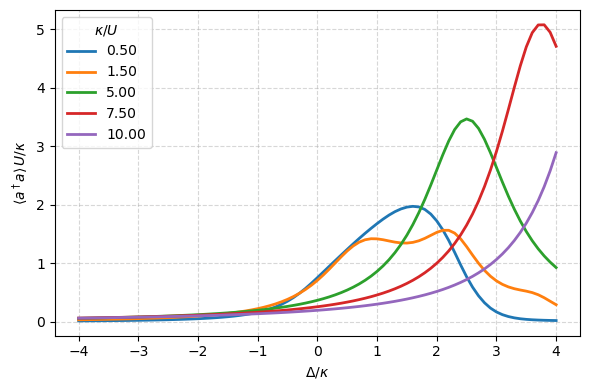

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import destroy, steadystate, expect

# -------- Parameters --------
N = 80                        # Hilbert-space cutoff
kappa = 1                   # decay rate (not fixed to 1)
U_list = [0.5, 1.5, 5.0, 7.5, 10.0]   # Kerr strengths
G_over_kappa = 1.0            # fixed ratio
G = G_over_kappa * kappa      # pump strength

# -------- Operators --------
a = destroy(N)
c_ops = [np.sqrt(kappa) * a]  # Lindblad term for photon loss

# -------- Hamiltonian builder --------
def H(delta, U, G, a):
    """Parametrically driven Kerr Hamiltonian."""
    return (-delta * a.dag() * a
            + 0.5 * U * a.dag()**2 * a**2
            + 0.5 * G * (a.dag()**2 + a**2))



# -------- Sweep Δ/κ --------
deltas = np.linspace(-4 * kappa, 4 * kappa, 81)

plt.figure(figsize=(6,4))

for U in U_list:
    n_vals = []
    for delta in deltas:
        H_sys = H(delta, U, G, a)
        rho_ss = steadystate(H_sys, c_ops, method='direct')
        n_vals.append(expect(a.dag() * a, rho_ss))
    plt.plot(deltas / kappa, np.array(n_vals) * U / kappa, lw=2, label=f"{U/kappa:.2f}")

plt.xlabel(r"$\Delta/\kappa$")
plt.ylabel(r"$\langle a^\dagger a\rangle\,U/\kappa$")
plt.legend(title=r"$\kappa/U$")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


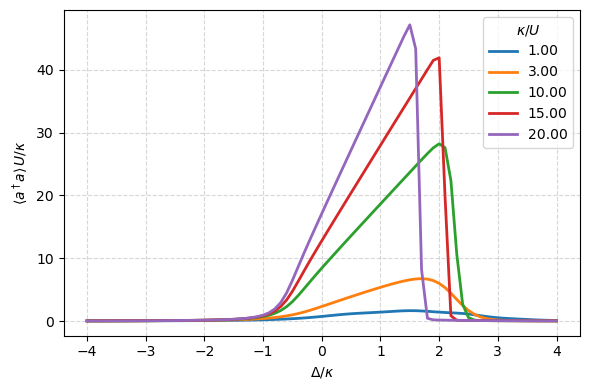

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import destroy, steadystate, expect

# Parameters
N = 80
kappa = 1.0  # keep symbolic
U_list = [1, 1/3, 1/10, 1/15, 1/20]  # corresponds to kappa/U = 4, 3, 2, 1, 0.33
G_over_kappa = 1.0
G = G_over_kappa * kappa

# Operators
a = destroy(N)
c_ops = [np.sqrt(1.0) * a]  # normalized decay

# Detuning sweep
deltas = np.linspace(-4, 4, 81)  # normalized Δ/κ

plt.figure(figsize=(6,4))

for U in U_list:
    U_over_kappa = U / kappa
    G_over_kappa = G / kappa
    n_vals = []
    for delta in deltas:
        H_scaled = (-delta * a.dag() * a
                    + 0.5 * U_over_kappa * a.dag()**2 * a**2
                    + 0.5 * G_over_kappa * (a.dag()**2 + a**2))
        rho_ss = steadystate(H_scaled, c_ops, method='iterative')
        n_vals.append(expect(a.dag() * a, rho_ss))
    plt.plot(deltas, np.array(n_vals) * G_over_kappa, lw=2, label=f"{kappa/U:.2f}")

plt.xlabel(r"$\Delta/\kappa$")
plt.ylabel(r"$\langle a^\dagger a\rangle\,U/\kappa$")
plt.legend(title=r"$\kappa/U$")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


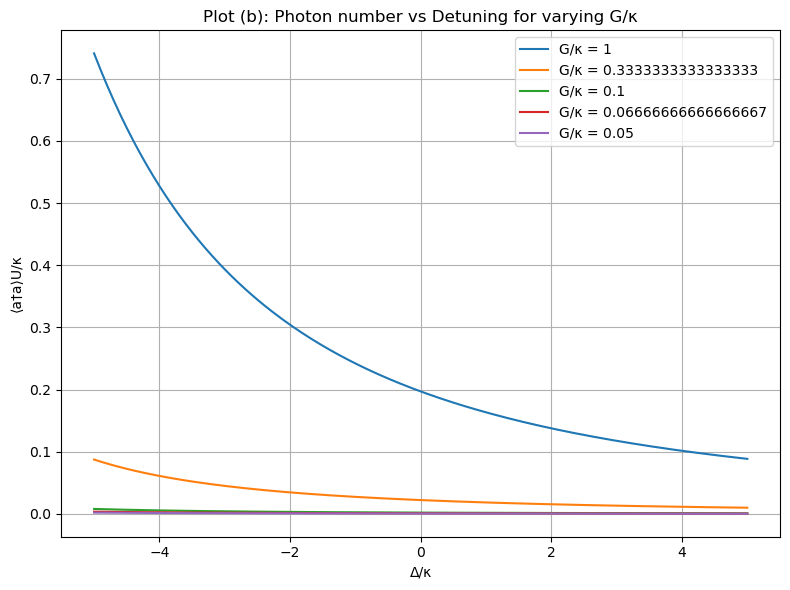

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# System parameters
kappa = 1.0           # cavity decay rate
U = 10.0              # Kerr nonlinearity
kappa_U = kappa / U   # fixed ratio
N = 20                # Hilbert space dimension
a = destroy(N)        # annihilation operator

# Detuning range
delta_vals = np.linspace(-5, 5, 200)

# G/kappa values to simulate
G_kappa_vals = [1, 1/3, 1/10, 1/15, 1/20]

# Prepare plot
plt.figure(figsize=(8, 6))

# Loop over G/kappa values
for G_kappa in G_kappa_vals:
    G = G_kappa * kappa
    photon_nums = []

    for delta in delta_vals:
        # Hamiltonian: H = Δ a†a + U a†² a² + G (a² + a†²)
        H = delta * a.dag() * a + U * a.dag() * a.dag() * a * a + G * (a * a + a.dag() * a.dag())
        c_ops = [np.sqrt(kappa) * a]
        rho_ss = steadystate(H, c_ops)
        photon_num = expect(a.dag() * a, rho_ss)
        photon_nums.append(photon_num * U / kappa)  # scaled as ⟨a†a⟩U/κ

    plt.plot(delta_vals, photon_nums, label=f'G/κ = {G_kappa}')

# Plot styling
plt.xlabel('Δ/κ')
plt.ylabel('⟨a†a⟩U/κ')
plt.title('Plot (b): Photon number vs Detuning for varying G/κ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
